# **ESERCIZIO 10.1**

**OBIETTIVI**

L'obiettivo di questo esercizio è parallelizzare con le librerie MPI il codice dell’Algoritmo Genetico (già realizzato nell'esercitazione precedente) per risolvere il problema del commesso viaggiatore, eseguendo una ricerca genetica con 11 ricerche GA parallele del percorso ottimale. In particolare, ogni nodo deve eseguire una ricerca GA indipendente, detta Continente; inoltre, ogni $N_{migr}$ generazioni, i continenti devono scambiarsi casualmente i loro migliori individui.

**IMPLEMENTAZIONE**

Ho aggiunto un nuovo metodo alla classe algoritmo genetico, in cui ho implementato la migrazione: 

    void AlgoritmoGenetico::Migrazione_MPI(int rank, int size)

In particolare, in questa funzione ho implementato lo scambio periodico di individui tra i diversi processi MPI che rappresentano i continenti dell’algoritmo genetico. Ogni rank seleziona il proprio individuo migliore (popolazione ordinata) e partecipa a una rete di scambio basata su una permutazione casuale globale dei rank, generata dal processo 0 e condivisa tramite broadcast. Tale permutazione definisce una sorta du anello tra i continenti, in cui ciascun processo invia il proprio miglior individuo al vicino successivo e riceve un individuo dal vicino precedente. Lo scambio avviene tramite MPI_Sendrecv, garantendo comunicazione simultanea e senza deadlock. L’individuo ricevuto viene infine inserito nella popolazione locale sostituendo il peggiore, mantenendo così costante la dimensione della popolazione e introducendo nuova diversità genetica nel sistema.

In particolare, ho scelto di effettuare una migrazione ogni 100 generazioni.

**MPI_Bcast**

Questa funzione serve a distribuire lo stesso dato a tutti i processi MPI. Nel codice viene usata dal rank 0 per comunicare a tutti i continenti la stessa permutazione casuale dei rank, contenuta nel vettore ordine. In questo modo ogni processo può determinare in maniera coerente da chi ricevere e a chi inviare il proprio miglior individuo. È un'operazione bloccante per ciascun processo: ogni processo non prosegue finché non ha completato la propria parte dell'operazione (invio per rank 0, ricezione per gli altri).

**MPI_Sendrecv**

Questa funzione permette  di effettuare simultaneamente una trasmissione e una ricezione tra processi MPI. Ogni rank invia il proprio miglior percorso al continente destinazione (dest) e contemporaneamente riceve un percorso dal continente sorgente (sorg). Questa operazione combinata evita possibili situazioni di deadlock che potrebbero verificarsi usando separatamente MPI_Send e MPI_Recv, in cui due processi potrebbero restare entrambi in attesa di ricevere dati. Nel programma, MPI_Sendrecv viene utilizzata per implementare uno scambio bidirezionale sicuro ed efficiente degli individui migliori tra i continenti.

# **ESERCIZIO 10.2**

**OBIETTIVI**

In questo esercizio devo applicare l'algoritmo genetico parallelo al problema del commesso viaggiatore, per cercare il percorso ottimale che colleghi i 110 capoluoghi di provincia italiani. In particolare, bisogna confrontare i risultati ottenuti utilizzando la migrazione e quelli ottenuti senza migrazione: utilizzare l'algoritmo genetico parallelizzato con migrazioni migliora rispetto a quello senza migrazioni?

**IMPLEMENTAZIONE**

Il codice esegue due simulazioni diverse: una con migrazioni tra i diversi rank e una senza migrazioni, per poi confrontare i risultati e capire quale sia il metodo più conveniente. In particolare, per differenziare le evoluzioni con migrazione da quelle senza, passo alla funzione Evoluzione un booleano, che comunica se far evolvere la popolazione usando o meno le mirgazioni.

Nel codice, prima di tutto inizializzo MPI:

        MPI_Init(&argc, &argv);
Questa funzione avvia l’ambiente parallelo e permette ai vari processi di comunicare tra loro.

Successivamente, 
        
        MPI_Comm_size(MPI_COMM_WORLD, &size);
        MPI_Comm_rank(MPI_COMM_WORLD, &rank);
$size$ indica il numero totale di processi MPI (quanti siamo?), mentre $rank$ identifica il singolo processo corrente (chi sono io?).

Ogni rank esegue lo stesso programma ma lavora indipendentemente sulla propria popolazione genetica. Infatti, devo inizializzare il generatore casuale in modo che ciascun rank sia associato a un seed diverso, così da non avere la stessa evoluzione in ogni rank. In particolare, ho deciso di modificare ciascun seed aggiungendo il valore del rank, in modo che tutti i rank abbiano dei seed sicuramente diversi tra loro.

        seed[0]+=rank;
        seed[1]+=rank;
        seed[2]+=rank;
        seed[3]+=rank;

Successivamente definisco i parametri evolutivi: ho scelto di eseguire 2000 generazioni da 200 individui ciascuna.

Per quanto riguarda l'evoluzione con migrazione, ogni rank evolve la propria popolazione; periodicamente, ogni 100 generazioni, i rank si scambiano i migliori individui. Inoltre, apro un file output per ciascun rank, così che durante l’evoluzione il programma possa salvare generazione e valore della funzione costo $L(1)$. Al termine dell’evoluzione ogni rank estrae il proprio miglior percorso e ne calcola la lunghezza. 

Successivamente viene usata:

        MPI_Gather

per raccogliere nel rank 0 la lunghezza del miglior percorso trovato da ciascun processo.

Il rank 0 individua quindi il processo che ha ottenuto il valore minimo della funzione costo tramite:

        min_element

L'identificativo del rank che ha ottenuto il risultato migliore viene infine distribuito a tutti i processi tramite MPI_Bcast. Successivamente ogni rank salva il miglior percorso ottenuto localmente durante la propria evoluzione genetica in un apposito file, aggiungendo alla fine la città iniziale per chiudere il percorso.

Successivamente il programma esegue una simulazione senza migrazioni, in cui ogni popolazione di ciascun rank evolve separatamente. Anche in questo caso salvo, per ciascun rank, generazione e lunghezza L(1) e, in un altro file, il percorso migliore come sequenza delle coordinate di ciascuna città.

Infine, chiudo il codice con:

        MPI_Finalize();
per chiudere l’ambiente MPI e terminare l’esecuzione parallela.


Rank         Con migrazione     Senza migrazione
0                   65.7142              71.5085
1                   65.7142              70.2241
2                   65.7142              70.4059
3                   65.7142              69.4038
4                   65.7142              69.7451
5                   65.7142              67.4055
6                   65.7142              67.8990
7                   65.7142              69.4006
8                   65.7142              72.6801
9                   65.7142              67.7268
10                  65.7142              69.8172
Minimo              65.7142              67.4055
Media               65.7142              69.6561


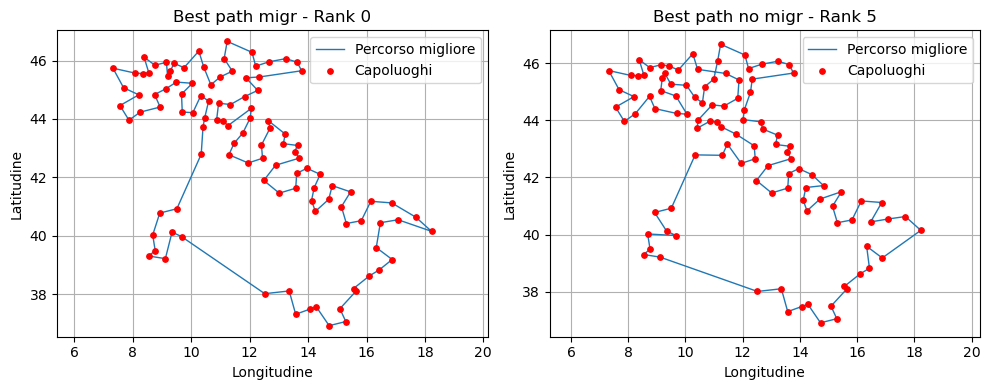

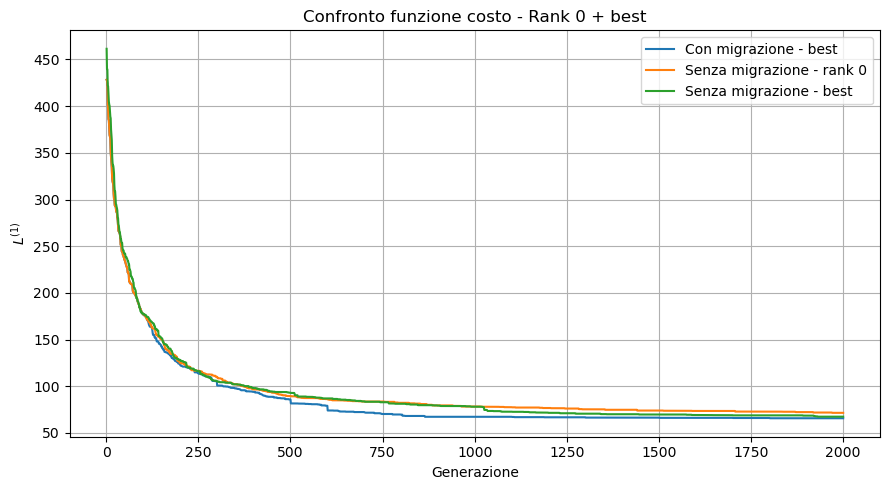

In [2]:
import numpy as np
import matplotlib.pyplot as plt

##################################################
# tabella confronto rank con e senza migrazione
##################################################

N_rank = 11

#stampo intestazione tabella
print("\n" + "="*60)
print(f"{'Rank':<6} {'Con migrazione':>20} {'Senza migrazione':>20}") #<6:allineamento a sx con 6 caratteri; >20:allineamento a dx
print("="*60)

L1_migr_final = []
L1_solo_final = []

for r in range(N_rank):  #scorro su tutti i rank

    try:
        #apro i file che contengono, per ciascuna generazione, il valore di L1 migliore e la media della metà migliore della popoalzione
        dati_migr = np.loadtxt(f"10.1/fileout_rank_{r}.dat") #legge file relativo a rank r-esimo (con migrazione)
        dati_solo = np.loadtxt(f"10.1/fileout_solo_rank_{r}.dat") #legge file relativo a rank r-esimo (senza migrazione)

        Lm = dati_migr[-1,1]  #legge file ultimo percorso (=percorso migliore): -1=ultima riga; 1=seconda colonna
        Ls = dati_solo[-1,1]

        L1_migr_final.append(Lm)  #aggiungo i risultati alla fine di ogni lista
        L1_solo_final.append(Ls)

        print(f"{r:<6} {Lm:>20.4f} {Ls:>20.4f}") #stampo in colonna 1 il rank, nella 2 il valore con migr nella 3 quello senza migr

    except:
        print(f"{r:<6} {'N/A':>20} {'N/A':>20}")

print("="*60)

#stampo il minimo percorso per entrambi i casi (con e senza migr), per ciascun rank
print(f"{'Minimo':<6} "
      f"{min(L1_migr_final):>20.4f} "
      f"{min(L1_solo_final):>20.4f}")

#stampo la media tra le diverse lunghezze del percorso
print(f"{'Media':<6} "
      f"{np.mean(L1_migr_final):>20.4f} "
      f"{np.mean(L1_solo_final):>20.4f}")

print("="*60)

##################################################
# stampo percorso migliore con migrazione (rank 0) e senza migrazione (rank 5)
##################################################


#considero i risultati del primo rank
rank = 0

#coordinate capoluoghi
coord = np.loadtxt("10.1/cap_prov_ita.dat")

best_migr = np.loadtxt(f"10.1/best_path_rank_{rank}.dat")
best_solo=np.loadtxt("10.1/best_solo_5.dat")

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
# percorso migliore rank 0: colonna 0: latitudine, colonna 1: longitudine delle città del percorso
plt.plot(best_migr[:,0],best_migr[:,1],'-',linewidth=1,markersize=3,label="Percorso migliore")
# Stampo cpoluoghi provincia
plt.scatter(coord[:,0],coord[:,1],color='red',s=15,zorder=5,label="Capoluoghi")

plt.title("Best path migr - Rank 0")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.axis("equal") #stessa scala su x e y
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.subplot(1, 2, 2)
# percorso migliore rank 0: colonna 0: latitudine, colonna 1: longitudine delle città del percorso
plt.plot(best_solo[:,0],best_solo[:,1],'-',linewidth=1,markersize=3,label="Percorso migliore")
# Stampo cpoluoghi provincia
plt.scatter(coord[:,0],coord[:,1],color='red',s=15,zorder=5,label="Capoluoghi")

plt.title("Best path no migr - Rank 5")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.axis("equal") #stessa scala su x e y
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

##################################################
#stampo andamento funzione costo con e senza migrazione (rank 0 + best rank senza migrazione)
##################################################

dati_migr = np.loadtxt(f"10.1/fileout_rank_{rank}.dat")
dati_solo = np.loadtxt(f"10.1/fileout_solo_rank_{rank}.dat")
dati_solo_best = np.loadtxt("10.1/fileout_solo_rank_5.dat")

gen_migr = dati_migr[:,0]
L1_migr  = dati_migr[:,1]

gen_solo = dati_solo[:,0]
L1_solo  = dati_solo[:,1]

gen_solo_best = dati_solo_best[:,0]
L1_solo_best  = dati_solo_best[:,1]

plt.figure(figsize=(9,5))

plt.plot(gen_migr, L1_migr,label="Con migrazione - best",linewidth=1.5)
plt.plot(gen_solo, L1_solo,linewidth=1.5,label="Senza migrazione - rank 0")
plt.plot(gen_solo_best, L1_solo_best,linewidth=1.5,label="Senza migrazione - best")

plt.xlabel("Generazione")
plt.ylabel("$L^{(1)}$")
plt.title("Confronto funzione costo - Rank 0 + best")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**COMMENTO AI RISULTATI**

Dal confronto con i risultati ottenuti è evidente che la migrazione giochi un ruolo vantaggioso: serve infatti per aumentare la diversità genetica, permette di evitare minimi locali e nel complesso migliora la convergenza globale.

In particoalre, analizzando la tabella che riporta il confronto tra l’algoritmo genetico eseguito con migrazione tra rank MPI e lo stesso algoritmo eseguito senza alcuna comunicazione tra processi, si nota che tutti i rank convergono esattamente allo stesso valore finale della funzione costo: 65.7142. Questo indica che la migrazione degli individui tra popolazioni ha permesso una rapida diffusione delle soluzioni migliori all’interno di tutti i processi MPI, accelerando la convergenza globale dell’algoritmo.

Al contrario, nel caso senza migrazione, ogni popolazione evolve indipendentemente. I valori finali della funzione costo risultano infatti differenti da rank a rank e mediamente più elevati. Il miglior risultato ottenuto senza migrazione è: 67.4055.

L’analisi grafica del miglior percorso senza migrazione mostra inoltre la presenza di un incrocio. Un percorso con incroci non può essere ottimale, dal momento che eliminando l’incrocio si ottiene sempre una riduzione della lunghezza totale del cammino. La presenza dell’incrocio potrebbe significare che l’algoritmo senza migrazione sia rimasto bloccato in un minimo locale.

Nel caso con migrazione, invece, il percorso migliore non presenta incroci ed appare più regolare e compatto. Questo comportamento conferma che lo scambio periodico di individui migliora l’esplorazione dello spazio delle soluzioni e riduce il rischio di bloccarsi nei minimi locali.

Anche l’andamento temporale della funzione costo evidenzia differenze significative tra i due approcci: con migrazione, la funzione costo decresce più rapidamente nelle prime generazioni e raggiunge prima il plateau finale; senza migrazione, invece, la discesa della funzione costo è più lenta e meno stabile, segno di una ricerca evolutiva meno efficace.

Nel complesso, i risultati mostrano chiaramente che l’introduzione della migrazione tra rank MPI: accelera la convergenza, migliora la qualità della soluzione finale, evita più facilmente minimi locali, favorisce la diffusione delle migliori configurazioni genetiche tra le popolazioni parallele.